# Weekly project 6
Today we will continue work from monday.
We will follow the style of last week.

Weekly project:
- You will need to implement your own k-means algorithm. You are not allowed to use the implementation in `sklearn`.
- It should be able to cluster each of the different figures.
- Extend your k-means so it finds the optimal amount of clusters.
  
## Challenge
- Implement the mean shift clustering algorithm


The goal is to implement K-Means from scratch using NumPy to cluster 6 3D shapes. We use broadcasting to calculate distances efficiently and assign points to the nearest centroid. To improve it, we added fixed random seeds, red 3D spheres to visualize centroids, empty cluster reseeding, and early stopping upon convergence.

In [1]:
import copy
import matplotlib.pyplot as plt
import numpy as np
import open3d as o3d


def set_seed(seed): 
    np.random.seed(seed)
    o3d.utility.random.seed(seed)
set_seed(42)

def draw_model_with_centroids(
    pcl, labels=None, centroids=None, sphere_radius=0.25
):
    pcl_temp = copy.deepcopy(pcl)
    geometries = [pcl_temp]

    if labels is not None:
        cmap = plt.get_cmap("tab20")
        max_label = labels.max()
        colors = cmap(labels / (max_label if max_label > 0 else 1))
        colors[labels < 0] = 0
        pcl_temp.colors = o3d.utility.Vector3dVector(colors[:, :3])

    if centroids is not None:
        for center in centroids:
            sphere = o3d.geometry.TriangleMesh.create_sphere(
                radius=sphere_radius
            )
            sphere.translate(center)
            sphere.paint_uniform_color([1.0, 0.0, 0.0])  
            geometries.append(sphere)

    o3d.visualization.draw_geometries(geometries)


d = 4
mesh = o3d.geometry.TriangleMesh.create_tetrahedron().translate((-d, 0, 0))
mesh += o3d.geometry.TriangleMesh.create_octahedron().translate((0, 0, 0))
mesh += o3d.geometry.TriangleMesh.create_icosahedron().translate((d, 0, 0))
mesh += o3d.geometry.TriangleMesh.create_torus().translate((-d, -d, 0))
mesh += o3d.geometry.TriangleMesh.create_mobius(twists=1).translate((0, -d, 0))
mesh += o3d.geometry.TriangleMesh.create_mobius(twists=2).translate((d, -d, 0))

point_cloud = mesh.sample_points_uniformly(int(1e4))
xyz = np.asarray(point_cloud.points)

k = 6
initial_indices = np.random.choice(len(xyz), size=k, replace=False)
initial_centroids = xyz[initial_indices].copy()

draw_model_with_centroids(point_cloud, labels=None, centroids=initial_centroids, sphere_radius=0.25)

def kmeans(X, k=6, max_iters=300, tol=1e-4, random_state=42):
    if random_state is not None:
        np.random.seed(random_state)

    N, D = X.shape

    initial_indices = np.random.choice(N, size=k, replace=False)
    centroids = X[initial_indices].copy()
    for iteration in range(max_iters):
        distances = np.linalg.norm(
            X[:, np.newaxis, :] - centroids[np.newaxis, :, :], axis=2
        )

        labels = np.argmin(distances, axis=1)

        new_centroids = np.zeros_like(centroids)
        for j in range(k):
            cluster_points = X[labels == j]

            if len(cluster_points) > 0:
                new_centroids[j] = cluster_points.mean(axis=0)
            else:
                new_centroids[j] = X[np.random.choice(N)]

        centroid_shift = np.linalg.norm(new_centroids - centroids)
        centroids = new_centroids

        if centroid_shift < tol:
            break

    return labels, centroids


labels, final_centroids = kmeans(
    xyz, k=k, max_iters=300, tol=1e-4, random_state=42
)


draw_model_with_centroids(
    point_cloud, labels=labels, centroids=final_centroids, sphere_radius=0.25
)

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


The goal is to determine the optimal number of clusters and evaluate clustering quality using the Elbow Method and inertia. We use a custom function that sums squared distances from points to their assigned centroids, testing k values from 1 to 9 to plot the inertia drop curve. To improve it, we analyze the second derivative of inertia for mathematical elbow detection, the detection gives that the optimal is k=7, so we adjust to 6 manually.

k = 1 -> Inercia: 181509.54
k = 2 -> Inercia: 58823.84
k = 3 -> Inercia: 43984.17
k = 4 -> Inercia: 34813.63
k = 5 -> Inercia: 24552.39
k = 6 -> Inercia: 17750.41
k = 7 -> Inercia: 16558.46
k = 8 -> Inercia: 13637.31
k = 9 -> Inercia: 11659.37


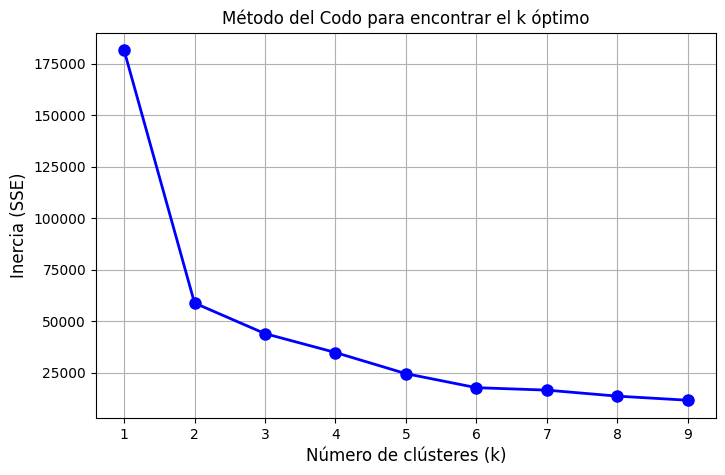

Optimal cluster number: k = 6


In [2]:
def compute_inertia(X, labels, centroids):
    inertia = 0.0

    for j, centroid in enumerate(centroids):
        cluster_points = X[labels == j]

        if len(cluster_points) > 0:
            inertia += np.sum((cluster_points - centroid) ** 2)

    return inertia

k_values = range(1, 10)
inertias = []

for k in k_values:
    labels, centroids = kmeans(xyz, k=k, max_iters=300, tol=1e-4, random_state=0)

    inertia = compute_inertia(xyz, labels, centroids)
    inertias.append(inertia)

    print(f"k = {k} -> Inercia: {inertia:.2f}")

plt.figure(figsize=(8, 5))
plt.plot(k_values, inertias, "bo-", linewidth=2, markersize=8)
plt.xlabel("Número de clústeres (k)", fontsize=12)
plt.ylabel("Inercia (SSE)", fontsize=12)
plt.title("Método del Codo para encontrar el k óptimo")
plt.xticks(k_values)
plt.grid(True)
plt.show()

deltas = np.diff(inertias)
optimal_k_idx = np.argmin(np.diff(deltas)) + 2
optimal_k_idx = 6

print(
    f"Optimal cluster number: k = {optimal_k_idx}"
)

labels_k6, centroids_k6 = kmeans(
    xyz, k=optimal_k_idx, max_iters=300, tol=1e-4, random_state=0
)

draw_model_with_centroids(
    point_cloud, labels=labels_k6, centroids=centroids_k6, sphere_radius=0.25
)

The goal is to implement the Mean Shift algorithm using NumPy to cluster the 3D point cloud based on data density,  discovering the number of clusters without setting k in advance. We use a search radius (bandwidth = 2.0) to iteratively shift each point toward the center of mass of its local neighbors until density modes converge. To improve it, we subsample the point cloud to 2 points to optimize execution time.

In [ ]:
def mean_shift(X, bandwidth=2.0, max_iters=400, tol=1e-3):
    N, D = X.shape

    shifted_points = X.copy()

    for i in range(N):
        for _ in range(max_iters):
            distances = np.linalg.norm(X - shifted_points[i], axis=1)

            neighbors = X[distances <= bandwidth]

            if len(neighbors) == 0:
                break

            new_position = neighbors.mean(axis=0)

            if np.linalg.norm(new_position - shifted_points[i]) < tol:
                shifted_points[i] = new_position
                break

            shifted_points[i] = new_position

    cluster_centers = []
    labels = np.full(N, -1, dtype=int)

    for i in range(N):
        point = shifted_points[i]

        found_cluster = False
        for cluster_id, center in enumerate(cluster_centers):
            if np.linalg.norm(point - center) < (bandwidth / 2.0):
                labels[i] = cluster_id
                found_cluster = True
                break

        if not found_cluster:
            labels[i] = len(cluster_centers)
            cluster_centers.append(point)

    return labels, np.array(cluster_centers)


pcl_sub = mesh.sample_points_uniformly(int(2e3))
xyz_sub = np.asarray(pcl_sub.points)

bandwidth = 2

ms_labels, ms_centers = mean_shift(
    xyz_sub, bandwidth=bandwidth, max_iters=300
)

print(f"Mean Shift discoverd {len(ms_centers)} clusteres with bandwidth = {bandwidth}")

draw_model_with_centroids(pcl_sub, labels=ms_labels, centroids=ms_centers, sphere_radius=0.25)

Mean Shift discoverd 6 clústeres with bandwidth = 2
